# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


#### **1.1.1**
Load the dataset

In [12]:
# Load the data
DATA_PATH = r"C:\Users\Niroj\Desktop\machine lea\Assignment\Car_Price_data.csv"
df = pd.read_csv(DATA_PATH)

# Display
df.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [16]:
# Find the proportion of missing values in each column and handle if found
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent.round(2)
}).sort_values('Missing_%', ascending=False)

print("Missing Value Summary:")
display(missing_df)

Missing Value Summary:


,Missing_Count,Missing_%
make_model,0,0.0
age,0,0.0
Drive_chain,0,0.0
Weight_kg,0,0.0
Displacement_cc,0,0.0
Gearing_Type,0,0.0
Upholstery_type,0,0.0
Paint_Type,0,0.0
Inspection_new,0,0.0
hp_kW,0,0.0


**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

Numerical Columns:
['price', 'km', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Displacement_cc', 'Weight_kg', 'cons_comb']


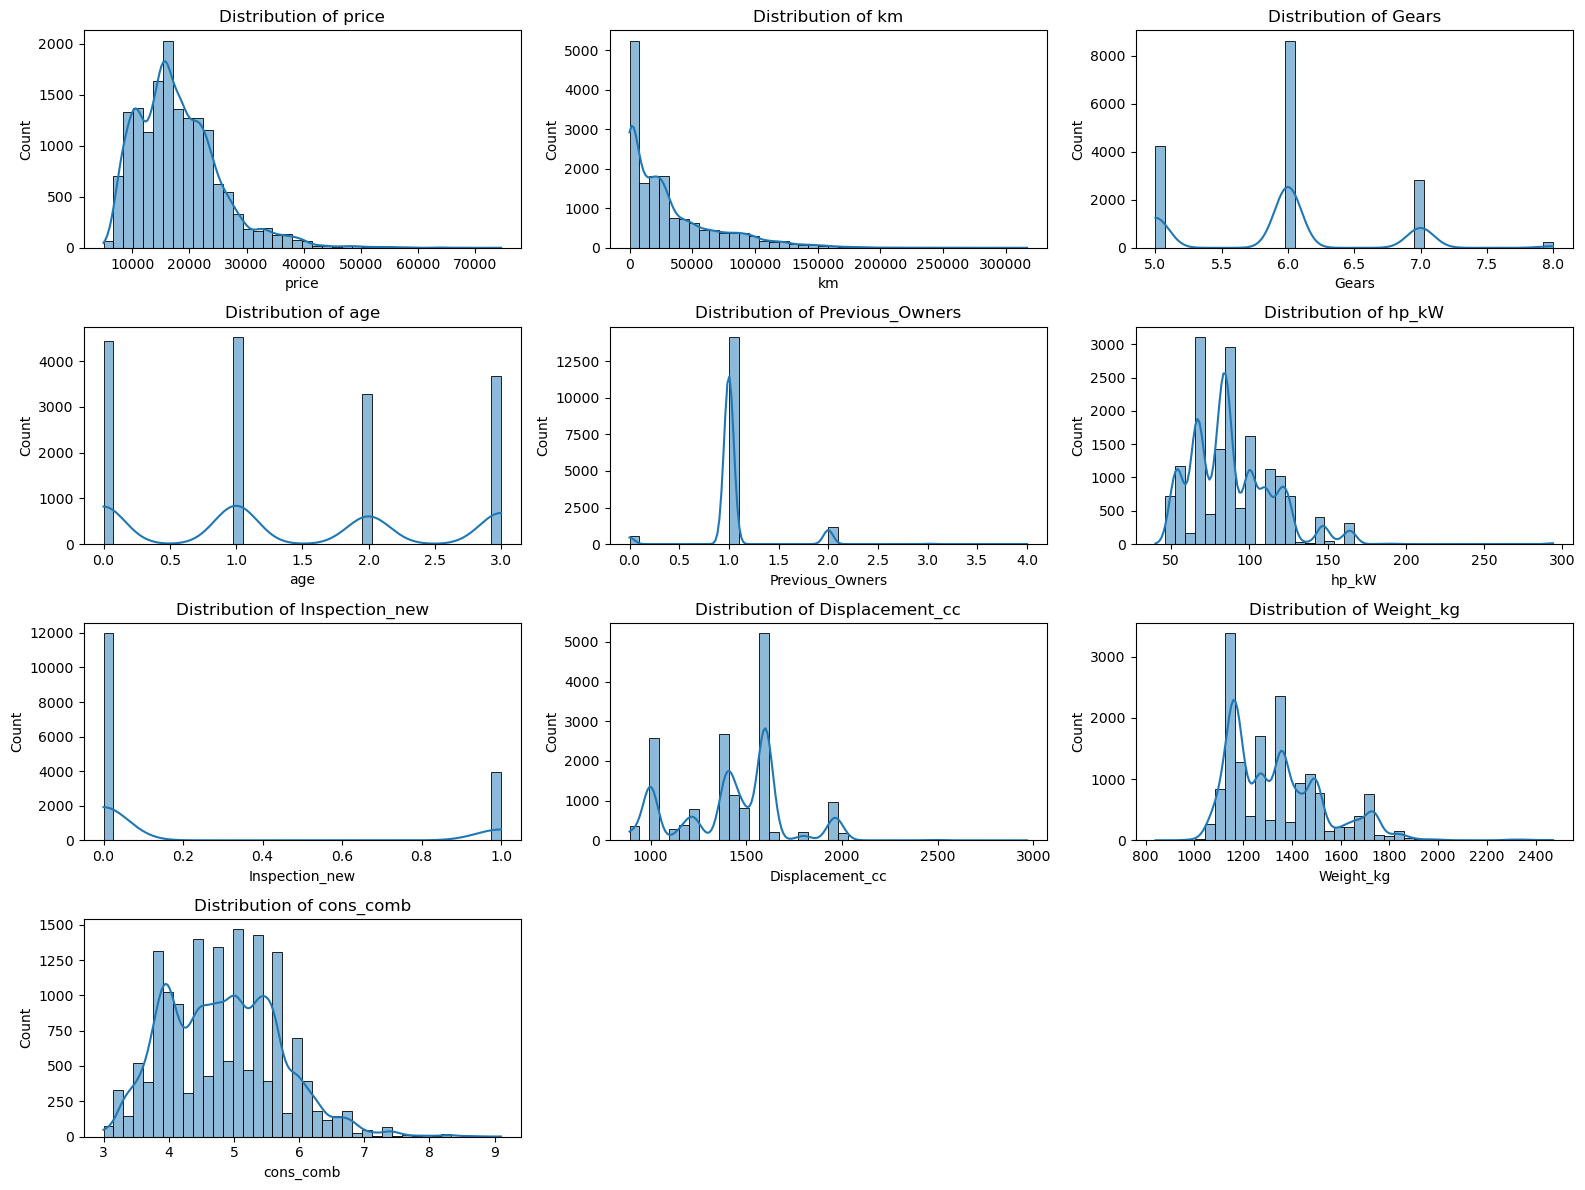

In [19]:
# Identify numerical features and plot histograms

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Columns:")
print(numeric_cols)

# Plot
plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols) // 3) + 1, 3, i)
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

Categorical Columns:
['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']
Categorical columns used for plotting:
['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']


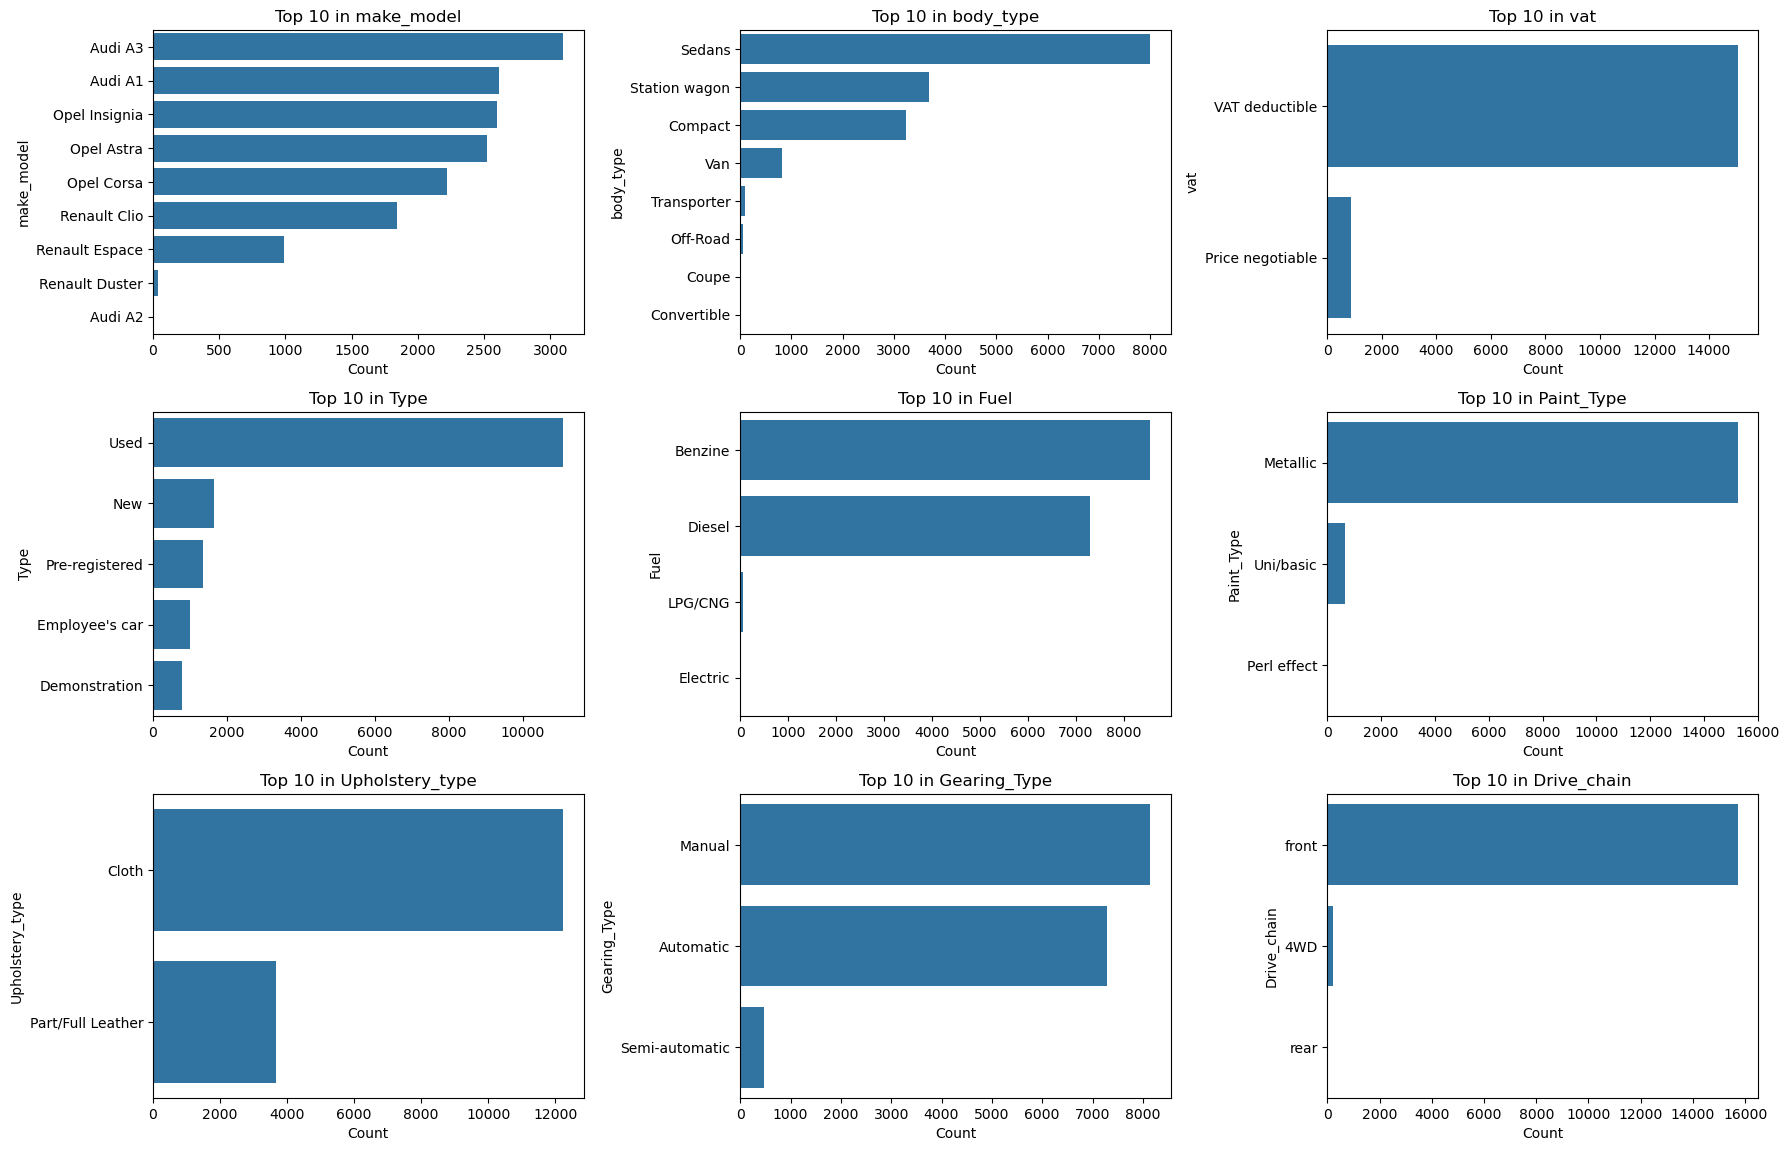

In [21]:
# Identify categorical columns and check their frequency distributions

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

# Columns that contain long comma-separated feature lists
spec_columns = ['Comfort_Convenience', 'Entertainment_Media', 
                'Safety_Security', 'Extras']

# Keep only simple categorical columns for plotting to avoid overlapping of long texts
simple_cat_cols = [col for col in categorical_cols if col not in spec_columns]

print("Categorical columns used for plotting:")
print(simple_cat_cols)

# Plot
plt.figure(figsize=(18, 15))

for i, col in enumerate(simple_cat_cols, 1):
    plt.subplot((len(simple_cat_cols) // 3) + 1, 3, i)

    top_counts = df[col].value_counts().head(10)
    sns.barplot(x=top_counts.values, y=top_counts.index)

    plt.title(f"Top 10 in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [25]:
# Fix columns as needed

# Fix 'Type' column
print("Original 'Type' distribution:")
display(df['Type'].value_counts())

# Group similar car conditions based on given explanation
type_mapping = {
    'New': 'New_like',
    'Pre-registered': 'New_like',
    "Employee's car": 'New_like',
    'Demonstration': 'New_like',
    'Used': 'Used'
}

df['Type_cleaned'] = df['Type'].map(type_mapping)

print("\nCleaned 'Type' distribution:")
display(df['Type_cleaned'].value_counts())


Original 'Type' distribution:


Type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796
Name: count, dtype: int64


Cleaned 'Type' distribution:


Type_cleaned
Used        11095
New_like     4820
Name: count, dtype: int64

In [26]:
# Fixing low-frequency categories in other columns

# Exclude text-heavy specification columns
spec_cols = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security'
]

# Identify categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove spec columns from this step
cat_cols = [c for c in cat_cols if c not in spec_cols]

# Define frequency threshold (1%)
threshold = 0.01 * len(df)

for col in cat_cols:
    value_counts = df[col].value_counts()
    rare_labels = value_counts[value_counts < threshold].index
    df[col] = df[col].replace(rare_labels, 'Other')

# Check updated distributions
print("Updated categorical distributions (top 5 values):")
for col in cat_cols:
    print(f"\n{col}")
    display(df[col].value_counts().head())

Updated categorical distributions (top 5 values):

make_model


make_model
Audi A3          3097
Audi A1          2614
Opel Insignia    2598
Opel Astra       2525
Opel Corsa       2216
Name: count, dtype: int64


body_type


body_type
Sedans           8004
Station wagon    3677
Compact          3240
Van               817
Other             177
Name: count, dtype: int64


vat


...

Gearing_Type
Manual            8149
Automatic         7297
Semi-automatic     469
Name: count, dtype: int64


Drive_chain


Drive_chain
front    15707
4WD        204
Other        4
Name: count, dtype: int64


Type_cleaned


Type_cleaned
Used        11095
New_like     4820
Name: count, dtype: int64

In [27]:
# Drop original Type column if Type_cleaned exists
if 'Type_cleaned' in df.columns and 'Type' in df.columns:
    df.drop(columns=['Type'], inplace=True)

print("Final categorical columns ready for encoding:")
display(df.select_dtypes(include=['object','category']).columns.tolist())

Final categorical columns ready for encoding:


['make_model',
 'body_type',
 'vat',
 'Fuel',
 'Comfort_Convenience',
 'Entertainment_Media',
 'Extras',
 'Safety_Security',
 'Paint_Type',
 'Upholstery_type',
 'Gearing_Type',
 'Drive_chain',
 'Type_cleaned']

#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

In [29]:
# Identify target variable
target_col = 'price'
print(f"Target variable identified as: {target_col}")

Target variable identified as: price


Text(0, 0.5, 'Count')

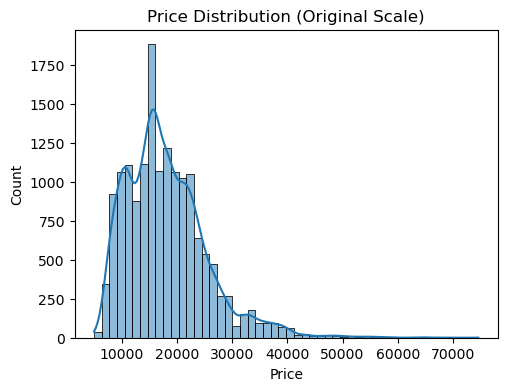

In [30]:
# Plot histograms for target feature

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df[target_col], bins=50, kde=True)
plt.title('Price Distribution (Original Scale)')
plt.xlabel('Price')
plt.ylabel('Count')


**The target variable seems to be skewed. Perform suitable transformation on the target.**

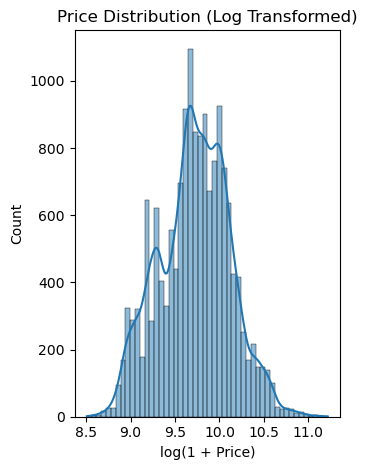

In [32]:
# Transform the target feature
# Apply log transformation (to handle right skewness)
df['log_price'] = np.log1p(df[target_col])

# Plot transformed distribution
plt.subplot(1,2,2)
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title('Price Distribution (Log Transformed)')
plt.xlabel('log(1 + Price)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [33]:
# Skewness comparison
print("Skewness comparison:")
print("Original price skewness:", round(df[target_col].skew(), 2))
print("Log-transformed price skewness:", round(df['log_price'].skew(), 2))

Skewness comparison:
Original price skewness: 1.24
Log-transformed price skewness: -0.03


### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

In [36]:
# Visualise correlation

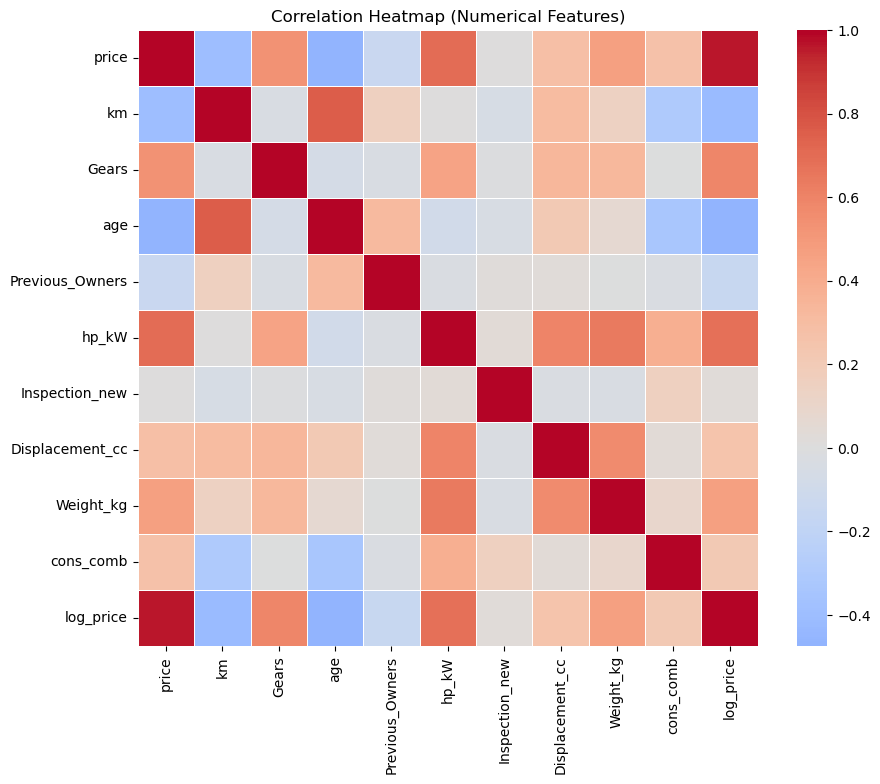

Top correlations with log_price:


log_price          1.000000
price              0.962281
hp_kW              0.678024
Gears              0.588194
Weight_kg          0.464597
Displacement_cc    0.254854
cons_comb          0.211097
Inspection_new     0.030927
Previous_Owners   -0.152029
km                -0.419189
age               -0.474618
Name: log_price, dtype: float64

In [37]:
# Correlation Map: Numerical Features vs Target
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Use log_price for better linear relationship
if 'log_price' in num_cols:
    target_for_corr = 'log_price'
else:
    target_for_corr = 'price'

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.5
)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

# Show top correlations with target
corr_target = corr_matrix[target_for_corr].sort_values(ascending=False)
print(f"Top correlations with {target_for_corr}:")
display(corr_target)

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

In [39]:
# Comparing average values of target for different categories

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude specification columns (handled separately)
spec_cols = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security'
]

categorical_cols = [c for c in categorical_cols if c not in spec_cols]

for col in categorical_cols:
    print(f"\nCategory-wise price comparison for: {col}")
    
    summary = (
        df.groupby(col)
        .agg(
            avg_price=('price', 'mean'),
            median_price=('price', 'median'),
            avg_log_price=('log_price', 'mean'),
            count=('price', 'count')
        )
        .sort_values('avg_price', ascending=False)
    )
    
    display(summary)


Category-wise price comparison for: make_model


,avg_price,median_price,avg_log_price,count
make_model,,,,
Renault Espace,30080.211907,28900.0,10.271724,991
Opel Insignia,21463.451886,19990.0,9.912658,2598
Audi A3,20996.693252,20900.0,9.928165,3097
Audi A1,18864.688982,17890.0,9.817643,2614
Opel Astra,15840.834059,15290.0,9.626041,2525
Other,13657.885714,13189.0,9.504893,35
Renault Clio,11940.320827,10650.0,9.335822,1839
Opel Corsa,11061.841606,10500.0,9.276059,2216



Category-wise price comparison for: body_type


,avg_price,median_price,avg_log_price,count
body_type,,,,
Van,30789.209302,29900.0,10.294540,817
Station wagon,18542.296981,17490.0,9.753456,3677
Sedans,17699.040480,17440.0,9.716144,8004
Other,17023.604520,14999.0,9.622932,177
Compact,15076.206481,14385.0,9.555735,3240



Category-wise price comparison for: vat


...

,avg_price,median_price,avg_log_price,count
Gearing_Type,,,,
Semi-automatic,23236.562900,21500.0,9.972004,469
Automatic,21163.176237,19900.0,9.906177,7297
Manual,14913.777396,14440.0,9.540276,8149



Category-wise price comparison for: Drive_chain


,avg_price,median_price,avg_log_price,count
Drive_chain,,,,
4WD,28261.416667,29995.0,10.133491,204
front,17892.109123,16890.0,9.715432,15707
Other,15332.500000,15925.0,9.606166,4



Category-wise price comparison for: Type_cleaned


,avg_price,median_price,avg_log_price,count
Type_cleaned,,,,
New_like,22127.53278,21900.0,9.928387,4820
Used,16241.84849,15850.0,9.630566,11095


### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

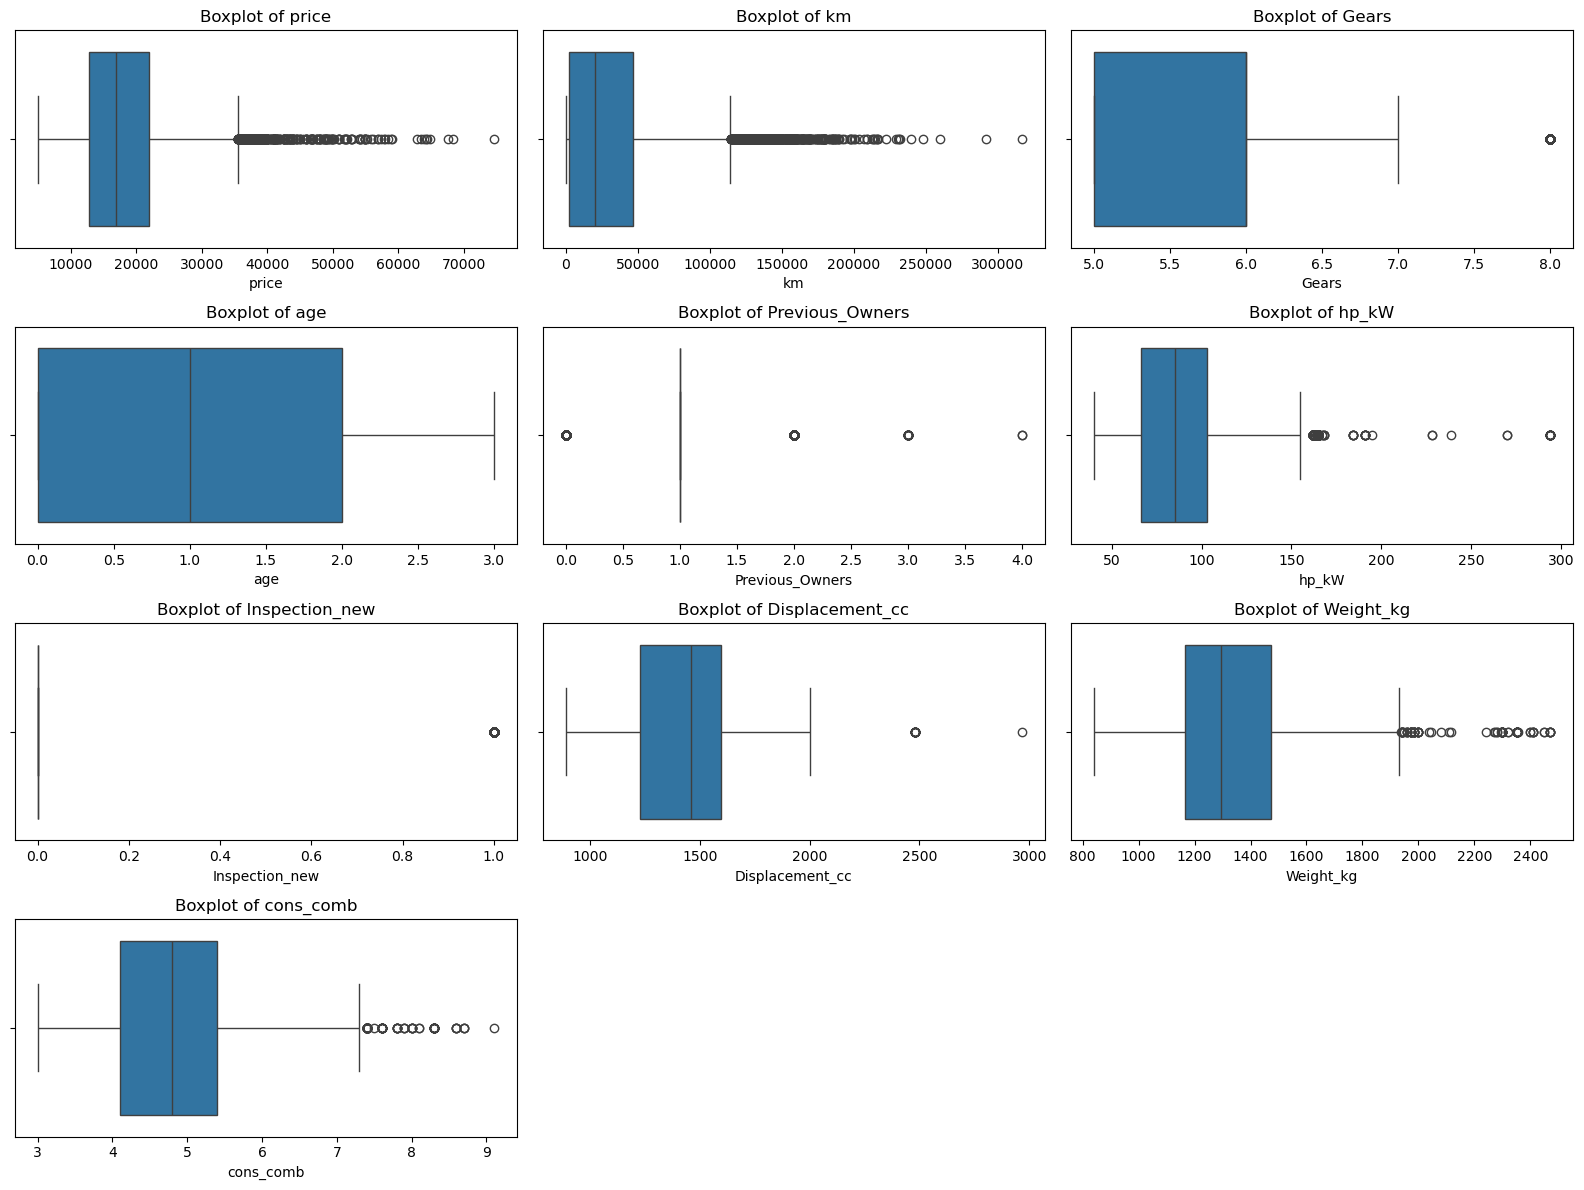

In [42]:
# Outliers present in each column

# Select numerical columns (exclude log_price for identification)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['log_price']]

# Boxplots to visually inspect outliers
plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) // 3) + 1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [44]:
# Handle outliers
outlier_cols = [
    'price',
    'km',
    'hp_kW',
    'Displacement_cc',
    'Weight_kg',
    'cons_comb'
]

# Apply percentile capping (Winsorization)
for col in outlier_cols:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("Outlier handling completed using 1st and 99th percentile capping.")

Outlier handling completed using 1st and 99th percentile capping.


### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [47]:
# Fix/create columns as needed

display(df.columns)

Index(['make_model', 'body_type', 'price', 'vat', 'km', 'Fuel', 'Gears',
       'Comfort_Convenience', 'Entertainment_Media', 'Extras',
       'Safety_Security', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new',
       'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc',
       'Weight_kg', 'Drive_chain', 'cons_comb', 'Type_cleaned', 'log_price'],
      dtype='object')

#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [50]:
# Check unique values in each feature spec column
spec_cols = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security'
]
# Check number of unique values and sample entries

for col in spec_cols:
     print(f"{col} → {df[col].nunique()} unique values")
    
# Create feature count variables
for col in spec_cols:
    # Count number of features (comma-separated)
    df[f'{col}_count'] = df[col].fillna('').apply(
        lambda x: len([item for item in x.split(',') if item.strip() != ''])
    )

print("Feature count columns created:")
display(df[[f'{col}_count' for col in spec_cols]].head())

Comfort_Convenience → 6196 unique values
Entertainment_Media → 346 unique values
Extras → 659 unique values
Safety_Security → 4442 unique values
Feature count columns created:


,Comfort_Convenience_count,Entertainment_Media_count,Extras_count,Safety_Security_count
0,16,4,3,14
1,9,5,4,15
2,13,2,2,12
3,16,8,3,14
4,13,7,4,13


Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [52]:
# Drop features from df
df.drop(columns=spec_cols, inplace=True)
print("Original specification columns dropped.")

Original specification columns dropped.


#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [54]:
# Encode features

from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns for encoding
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Specification columns should NOT be encoded here
spec_cols = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security'
]

categorical_cols = [c for c in categorical_cols if c not in spec_cols]

print("Categorical columns to be encoded:")
print(categorical_cols)

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")

Categorical columns to be encoded:
['make_model', 'body_type', 'vat', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain', 'Type_cleaned']
Shape before encoding: (15915, 24)
Shape after encoding: (15915, 37)


#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [56]:
# Split data
from sklearn.model_selection import train_test_split

# Target variable
y = df_encoded['log_price']   # using transformed target for modeling

# Features (drop both price and log_price from predictors)
X = df_encoded.drop(columns=['price', 'log_price'])

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Check shapes
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (12732, 35) (12732,)
Testing set shape: (3183, 35) (3183,)


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [58]:
# Scale features

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled testing set shape:", X_test_scaled.shape)

Scaled training set shape: (12732, 35)
Scaled testing set shape: (3183, 35)


## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [62]:
# Initialise and train model
from sklearn.linear_model import LinearRegression

# Initialise the model
lr_model = LinearRegression()

# Train (fit) the model on training data
lr_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [63]:
# Evaluate the model's performance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict on test data
y_test_pred = lr_model.predict(X_test_scaled)

# Evaluation metrics (on log scale)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Baseline Linear Regression Performance (on log-price):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

Baseline Linear Regression Performance (on log-price):
RMSE: 0.1097
MAE : 0.0828
R²  : 0.9248


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

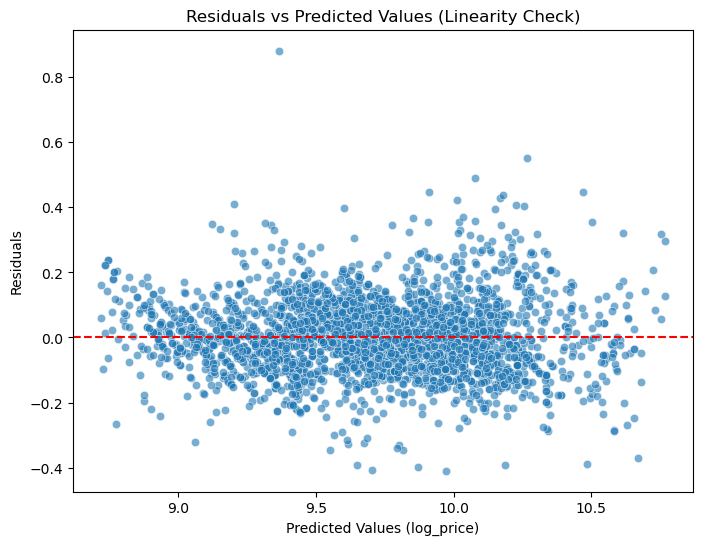

In [66]:
# Linearity check: Plot residuals vs fitted values

# Calculate residuals
residuals = y_test - y_test_pred

# Plot residuals vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6)

# Reference line at zero
plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Predicted Values (log_price)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values (Linearity Check)')
plt.show()

Check normality in residual distribution

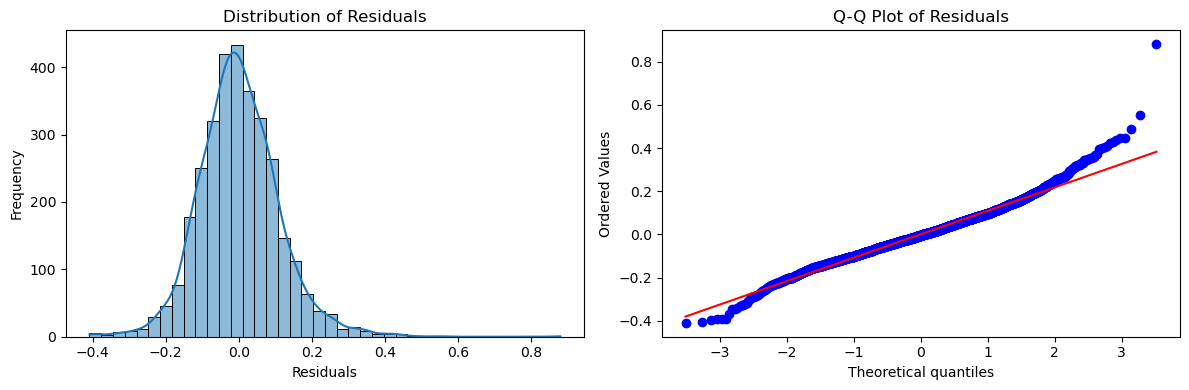

In [68]:
# Check the normality of residuals by plotting their distribution
import scipy.stats as stats

# Histogram with KDE
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuals, bins=40, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [70]:
# Check for multicollinearity and handle
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF should be computed on scaled numeric features
X_vif = X_train_scaled.copy()

# Convert numpy array to DataFrame
X_vif = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

# Add small noise to avoid singular matrix issues (safe & standard)
X_vif += np.random.normal(0, 1e-6, X_vif.shape)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Sort by highest VIF
vif_data = vif_data.sort_values("VIF", ascending=False)

display(vif_data.head(15))



,Feature,VIF
19,make_model_Renault Espace,8.744093
4,hp_kW,7.674592
25,Fuel_Diesel,6.694142
6,Displacement_cc,6.603739
23,body_type_Van,6.310543
16,make_model_Opel Insignia,5.184505
7,Weight_kg,4.249157
8,cons_comb,4.184032
15,make_model_Opel Corsa,3.991820
2,age,3.771346


### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [73]:
# List of alphas to tune for Ridge regularisation
ridge_alphas = np.logspace(-3, 3, 20)

print("Alpha values for Ridge regression:")
print(ridge_alphas)


Alpha values for Ridge regression:
[1.00000000e-03 2.06913808e-03 4.28133240e-03 8.85866790e-03
 1.83298071e-02 3.79269019e-02 7.84759970e-02 1.62377674e-01
 3.35981829e-01 6.95192796e-01 1.43844989e+00 2.97635144e+00
 6.15848211e+00 1.27427499e+01 2.63665090e+01 5.45559478e+01
 1.12883789e+02 2.33572147e+02 4.83293024e+02 1.00000000e+03]


#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [75]:
# Applying Ridge regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Initialise Ridge model
ridge_model = Ridge(random_state=42)

# Set up GridSearch with predefined alpha values
ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid={'alpha': ridge_alphas},
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

# Fit on scaled training data
ridge_grid.fit(X_train_scaled, y_train)

# Best alpha
best_ridge_alpha = ridge_grid.best_params_['alpha']
print("Best alpha for Ridge Regression:", best_ridge_alpha)

# Best model
best_ridge_model = ridge_grid.best_estimator_

Best alpha for Ridge Regression: 2.976351441631316


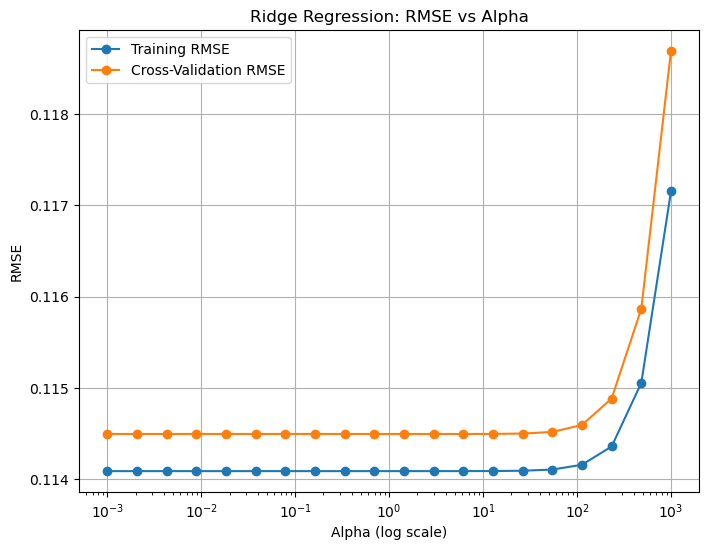

In [76]:
# Plot train and test scores against alpha
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error


train_rmse = []
cv_rmse = []

for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    
    # Train model
    ridge.fit(X_train_scaled, y_train)
    
    # Training RMSE
    train_pred = ridge.predict(X_train_scaled)
    train_rmse.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )
    
    # Cross-validated RMSE (negative because sklearn convention)
    cv_scores = cross_val_score(
        ridge,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    cv_rmse.append(-cv_scores.mean())

# Display
plt.figure(figsize=(8, 6))
plt.plot(ridge_alphas, train_rmse, marker='o', label='Training RMSE')
plt.plot(ridge_alphas, cv_rmse, marker='o', label='Cross-Validation RMSE')

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Ridge Regression: RMSE vs Alpha')
plt.legend()
plt.grid(True)
plt.show()


Find the best alpha value.

In [78]:
# Best alpha value

# Grid search using MAE
ridge_grid_mae = GridSearchCV(
    estimator=ridge,
    param_grid={'alpha': ridge_alphas},
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

# Fit on training data
ridge_grid_mae.fit(X_train_scaled, y_train)

best_alpha_ridge = ridge_grid_mae.best_params_['alpha']

# Best score (negative MAE)


best_score_ridge = ridge_grid_mae.best_score_

print("Best alpha value (Ridge):", best_alpha_ridge)
print("Best cross-validated score (Negative MAE):", best_score_ridge)

Best alpha value (Ridge): 54.555947811685144
Best cross-validated score (Negative MAE): -0.08498691977725338


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [81]:
# Take a smaller range of alpha to test
fine_ridge_alphas = np.linspace(
    best_alpha_ridge * 0.5,
    best_alpha_ridge * 1.5,
    15
)

print("Fine-tuning alpha range:")
print(fine_ridge_alphas)



Fine-tuning alpha range:
[27.27797391 31.17482732 35.07168074 38.96853415 42.86538757 46.76224098
 50.6590944  54.55594781 58.45280123 62.34965464 66.24650806 70.14336147
 74.04021489 77.9370683  81.83392172]


In [82]:
# Applying Ridge regression

ridge = Ridge(random_state=42)


# Grid search with MAE
ridge_fine_grid = GridSearchCV(
    estimator=ridge,
    param_grid={'alpha': fine_ridge_alphas},
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

# Fit model
ridge_fine_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(random_state=42), n_jobs=-1,
             param_grid={'alpha': array([27.27797391, 31.17482732, 35.07168074, 38.96853415, 42.86538757,
       46.76224098, 50.6590944 , 54.55594781, 58.45280123, 62.34965464,
       66.24650806, 70.14336147, 74.04021489, 77.9370683 , 81.83392172])},
             scoring='neg_mean_absolute_error')

Plot the error-alpha graph again and find the actual optimal value for alpha.

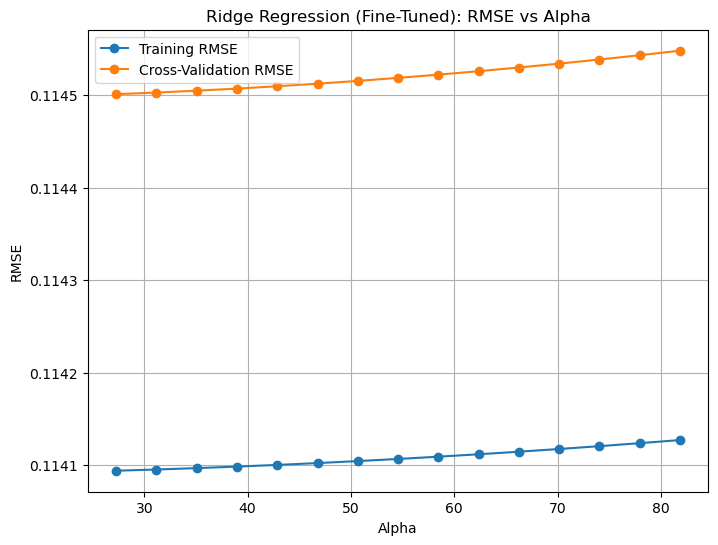

Best fine-tuned alpha (Ridge): 50.659094396564775
Best cross-validated MAE: 0.08498676666280816


In [84]:
# Plot train and test scores against alpha

train_rmse_fine = []
cv_rmse_fine = []

for alpha in fine_ridge_alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    
    # Fit on training data
    ridge.fit(X_train_scaled, y_train)
    
    # Training RMSE
    train_pred = ridge.predict(X_train_scaled)
    train_rmse_fine.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )
    
    # Cross-validated RMSE
    cv_scores = cross_val_score(
        ridge,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    cv_rmse_fine.append(-cv_scores.mean())

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fine_ridge_alphas, train_rmse_fine, marker='o', label='Training RMSE')
plt.plot(fine_ridge_alphas, cv_rmse_fine, marker='o', label='Cross-Validation RMSE')

plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Ridge Regression (Fine-Tuned): RMSE vs Alpha')
plt.legend()
plt.grid(True)
plt.show()


# Best alpha value

best_fine_alpha_ridge = ridge_fine_grid.best_params_['alpha']


# Best score (negative MAE)

best_fine_score_ridge = ridge_fine_grid.best_score_

print("Best fine-tuned alpha (Ridge):", best_fine_alpha_ridge)
print("Best cross-validated MAE:", -best_fine_score_ridge)

# Save final Ridge model
final_ridge_model = ridge_fine_grid.best_estimator_

In [85]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model

# Convert back to DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)


# Use the fine-tuned best alpha
ridge_final = Ridge(alpha=best_fine_alpha_ridge, random_state=42)

# Fit the model on scaled training data
ridge_final.fit(X_train_scaled_df, y_train)

print("Final Ridge model trained with alpha =", best_fine_alpha_ridge)

# Extract coefficients
ridge_coefficients = pd.DataFrame({
    'Feature': X_train_scaled_df.columns,
    'Coefficient': ridge_final.coef_
})

# Sort by absolute coefficient magnitude
ridge_coefficients['Abs_Coefficient'] = ridge_coefficients['Coefficient'].abs()
ridge_coefficients = ridge_coefficients.sort_values(
    by='Abs_Coefficient', ascending=False
)



Final Ridge model trained with alpha = 50.659094396564775


In [86]:
# Show the coefficients for each feature

display(ridge_coefficients.head(15))

,Feature,Coefficient,Abs_Coefficient
15,make_model_Opel Corsa,-0.143596,0.143596
18,make_model_Renault Clio,-0.120519,0.120519
4,hp_kW,0.112296,0.112296
2,age,-0.105135,0.105135
0,km,-0.087270,0.087270
14,make_model_Opel Astra,-0.079997,0.079997
30,Gearing_Type_Manual,-0.060812,0.060812
9,Comfort_Convenience_count,0.053407,0.053407
19,make_model_Renault Espace,0.036467,0.036467
13,make_model_Audi A3,0.035765,0.035765


In [87]:
# Evaluate the Ridge model on the test data

# Convert scaled test data to DataFrame (for consistency)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_train.columns,
    index=X_test.index
)
# Predict on test data
y_test_pred_ridge = ridge_final.predict(X_test_scaled_df)

# Evaluation metrics (log-price scale)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
r2_ridge = r2_score(y_test, y_test_pred_ridge)

print("Ridge Regression Performance (on log-price):")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"MAE : {mae_ridge:.4f}")
print(f"R²  : {r2_ridge:.4f}")


Ridge Regression Performance (on log-price):
RMSE: 0.1097
MAE : 0.0827
R²  : 0.9248


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [90]:
# List of alphas to tune for Lasso regularisation
lasso_alphas = np.logspace(-4, 0, 20)

print("Alpha values for Lasso regression:")
print(lasso_alphas)


Alpha values for Lasso regression:
[1.00000000e-04 1.62377674e-04 2.63665090e-04 4.28133240e-04
 6.95192796e-04 1.12883789e-03 1.83298071e-03 2.97635144e-03
 4.83293024e-03 7.84759970e-03 1.27427499e-02 2.06913808e-02
 3.35981829e-02 5.45559478e-02 8.85866790e-02 1.43844989e-01
 2.33572147e-01 3.79269019e-01 6.15848211e-01 1.00000000e+00]


#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [92]:
# Initialise Lasso regression model

from sklearn.linear_model import Lasso

# Initialise Lasso model
lasso_model = Lasso(
    random_state=42,
    max_iter=5000
)


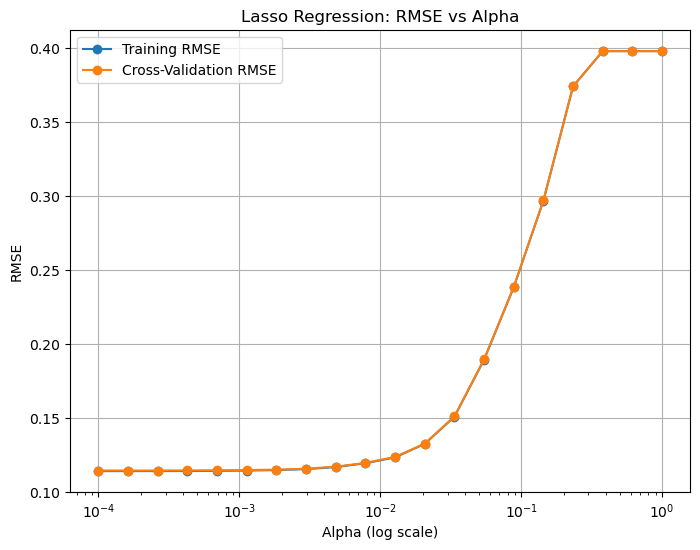

In [93]:
# Plot train and test scores against alpha
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

train_rmse_lasso = []
cv_rmse_lasso = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    
    # Fit model
    lasso.fit(X_train_scaled, y_train)
    
    # Training RMSE
    train_pred = lasso.predict(X_train_scaled)
    train_rmse_lasso.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )
    
    # Cross-validated RMSE
    cv_scores = cross_val_score(
        lasso,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    cv_rmse_lasso.append(-cv_scores.mean())

# Plot
plt.figure(figsize=(8, 6))
plt.plot(lasso_alphas, train_rmse_lasso, marker='o', label='Training RMSE')
plt.plot(lasso_alphas, cv_rmse_lasso, marker='o', label='Cross-Validation RMSE')

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Lasso Regression: RMSE vs Alpha')
plt.legend()
plt.grid(True)
plt.show()

In [94]:
# Best alpha value

# Grid search using MAE (as requested in earlier steps)
lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid={'alpha': lasso_alphas},
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

# Fit on scaled training data
lasso_grid.fit(X_train_scaled, y_train)

best_alpha_lasso = lasso_grid.best_params_['alpha']
print("Best alpha value (Lasso):", best_alpha_lasso)

# Best score (negative MAE)

best_score_lasso = lasso_grid.best_score_
print("Best cross-validated score (Negative MAE):", best_score_lasso)

Best alpha value (Lasso): 0.0001623776739188721
Best cross-validated score (Negative MAE): -0.08498952065272337


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [96]:
# List of alphas to tune for Lasso regularization

# Coarse alpha range for Lasso (log scale)
lasso_alphas = np.logspace(-4, 0, 20)

print("Alpha values for Lasso regularization:")
print(lasso_alphas)

Alpha values for Lasso regularization:
[1.00000000e-04 1.62377674e-04 2.63665090e-04 4.28133240e-04
 6.95192796e-04 1.12883789e-03 1.83298071e-03 2.97635144e-03
 4.83293024e-03 7.84759970e-03 1.27427499e-02 2.06913808e-02
 3.35981829e-02 5.45559478e-02 8.85866790e-02 1.43844989e-01
 2.33572147e-01 3.79269019e-01 6.15848211e-01 1.00000000e+00]


In [97]:
# Tuning Lasso hyperparameters

fine_lasso_alphas = np.linspace(
    best_alpha_lasso * 0.5,
    best_alpha_lasso * 1.5,
    15
)

print("Fine-tuned alpha values for Lasso regularization:")
print(fine_lasso_alphas)


Fine-tuned alpha values for Lasso regularization:
[8.11888370e-05 9.27872422e-05 1.04385648e-04 1.15984053e-04
 1.27582458e-04 1.39180863e-04 1.50779269e-04 1.62377674e-04
 1.73976079e-04 1.85574484e-04 1.97172890e-04 2.08771295e-04
 2.20369700e-04 2.31968106e-04 2.43566511e-04]


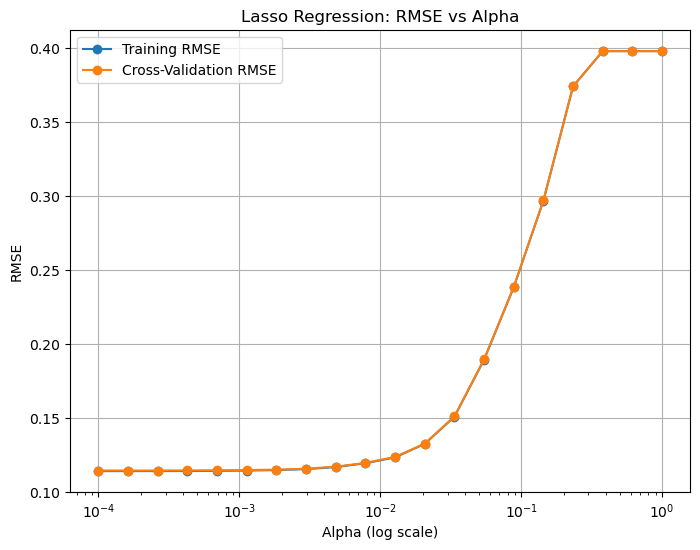

In [98]:
# Plot train and test scores against alpha

train_rmse_lasso = []
cv_rmse_lasso = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    
    # Fit model
    lasso.fit(X_train_scaled, y_train)
    
    # Training RMSE
    train_pred = lasso.predict(X_train_scaled)
    train_rmse_lasso.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )
    
    # Cross-validated RMSE
    cv_scores = cross_val_score(
        lasso,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    cv_rmse_lasso.append(-cv_scores.mean())

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(lasso_alphas, train_rmse_lasso, marker='o', label='Training RMSE')
plt.plot(lasso_alphas, cv_rmse_lasso, marker='o', label='Cross-Validation RMSE')

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Lasso Regression: RMSE vs Alpha')
plt.legend()
plt.grid(True)
plt.show()


In [99]:
# Best alpha value
best_alpha_lasso = lasso_grid.best_params_['alpha']
print("Best alpha value (Lasso):", best_alpha_lasso)

# Best score (negative MAE)
best_score_lasso = lasso_grid.best_score_
print("Best cross-validated score (Negative MAE):", best_score_lasso)



Best alpha value (Lasso): 0.0001623776739188721
Best cross-validated score (Negative MAE): -0.08498952065272337


In [100]:
# Set best alpha for Lasso regression
# Convert scaled training data to DataFrame 
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)

# Initialise Lasso with best alpha
lasso_final = Lasso(alpha=best_alpha_lasso,random_state=42,max_iter=5000)

# Fit the Lasso model on scaled training data
lasso_final.fit(X_train_scaled_df, y_train)

# Get the coefficients of the fitted model
lasso_coefficients = pd.DataFrame({
    'Feature': X_train_scaled_df.columns,
    'Coefficient': lasso_final.coef_
})

# Add absolute coefficient for importance ranking
lasso_coefficients['Abs_Coefficient'] = lasso_coefficients['Coefficient'].abs()


In [101]:
# Check the coefficients for each feature

# Sort by importance
lasso_coefficients = lasso_coefficients.sort_values(
    by='Abs_Coefficient', ascending=False
)

display(lasso_coefficients.head(15))


,Feature,Coefficient,Abs_Coefficient
15,make_model_Opel Corsa,-0.145172,0.145172
18,make_model_Renault Clio,-0.121741,0.121741
4,hp_kW,0.112276,0.112276
2,age,-0.106159,0.106159
0,km,-0.087002,0.087002
14,make_model_Opel Astra,-0.081497,0.081497
30,Gearing_Type_Manual,-0.061494,0.061494
9,Comfort_Convenience_count,0.053029,0.053029
19,make_model_Renault Espace,0.035182,0.035182
13,make_model_Audi A3,0.034799,0.034799


In [102]:
# Evaluate the Lasso model on the test data
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Convert scaled test data to DataFrame
X_test_scaled_df = pd.DataFrame(X_test_scaled,columns=X_train.columns,index=X_test.index)

# Predict on test data
y_test_pred_lasso = lasso_final.predict(X_test_scaled_df)

# Evaluation metrics (log-price scale)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
r2_lasso = r2_score(y_test, y_test_pred_lasso)

print("Lasso Regression Performance (on log-price):")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"MAE : {mae_lasso:.4f}")
print(f"R²  : {r2_lasso:.4f}")

Lasso Regression Performance (on log-price):
RMSE: 0.1097
MAE : 0.0828
R²  : 0.9248


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [105]:
# Compare metrics for each model
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE (log-price)': [rmse, rmse_ridge, rmse_lasso],
    'MAE (log-price)': [mae, mae_ridge, mae_lasso],
    'R² Score': [r2, r2_ridge, r2_lasso]
})

model_comparison



,Model,RMSE (log-price),MAE (log-price),R² Score
0,Linear Regression,0.109663,0.082777,0.924763
1,Ridge Regression,0.109656,0.082746,0.924772
2,Lasso Regression,0.109672,0.082777,0.924751


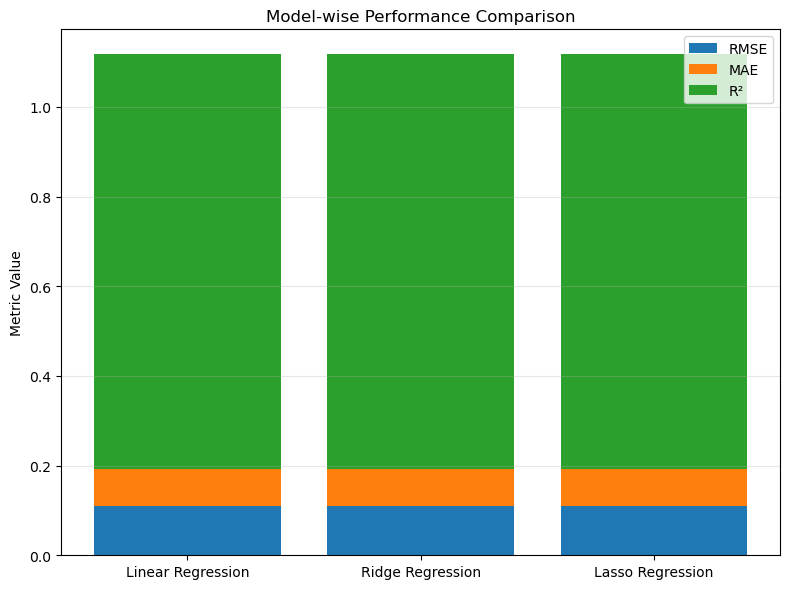

In [106]:
# Plot
models = model_comparison['Model']

rmse_vals = model_comparison['RMSE (log-price)']
mae_vals  = model_comparison['MAE (log-price)']
r2_vals   = model_comparison['R² Score']

plt.figure(figsize=(8, 6))

plt.bar(models, rmse_vals, label='RMSE')
plt.bar(models, mae_vals, bottom=rmse_vals, label='MAE')
plt.bar(models, r2_vals, bottom=rmse_vals + mae_vals, label='R²')

plt.ylabel('Metric Value')
plt.title('Model-wise Performance Comparison')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [109]:
# Compare highest coefficients and coefficients of eliminated features

coef_comparison = pd.DataFrame({
    'Feature': X_train_scaled_df.columns,
    'Linear': lr_model.coef_,
    'Ridge': ridge_final.coef_,
    'Lasso': lasso_final.coef_
})

# Add absolute values for comparison
coef_comparison['Abs_Linear'] = coef_comparison['Linear'].abs()
coef_comparison['Abs_Ridge']  = coef_comparison['Ridge'].abs()
coef_comparison['Abs_Lasso']  = coef_comparison['Lasso'].abs()

coef_comparison.head()

,Feature,Linear,Ridge,Lasso,Abs_Linear,Abs_Ridge,Abs_Lasso
0,km,-0.087273,-0.087270,-0.087002,0.087273,0.087270,0.087002
1,Gears,0.015889,0.017075,0.015986,0.015889,0.017075,0.015986
2,age,-0.105900,-0.105135,-0.106159,0.105900,0.105135,0.106159
3,Previous_Owners,-0.003101,-0.003225,-0.002905,0.003101,0.003225,0.002905
4,hp_kW,0.113487,0.112296,0.112276,0.113487,0.112296,0.112276


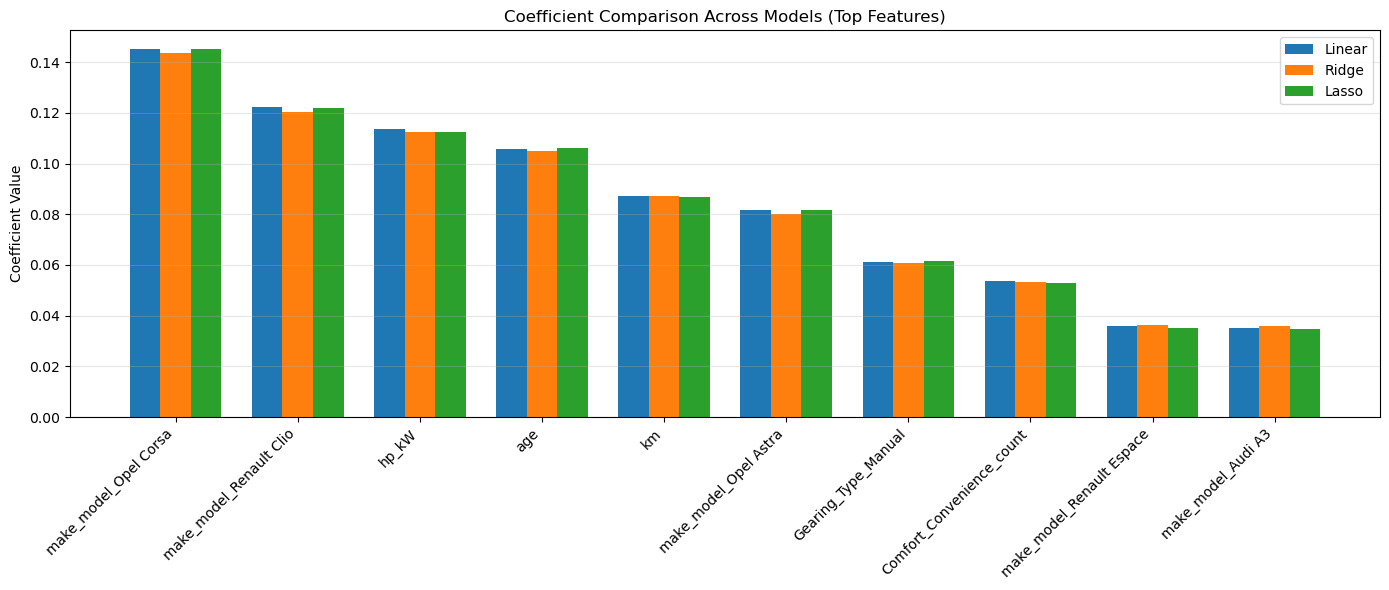

In [174]:
# Select top features based on Ridge importance (most stable)
top_n = 10
top_features = coef_comparison.sort_values(
    by='Abs_Ridge', ascending=False
).head(top_n)

# X-axis positions
x = np.arange(len(top_features))
width = 0.25

plt.figure(figsize=(14, 6))

# Plot bars
plt.bar(x - width, top_features['Abs_Linear'], width, label='Linear')
plt.bar(x,         top_features['Abs_Ridge'],  width, label='Ridge')
plt.bar(x + width, top_features['Abs_Lasso'],  width, label='Lasso')

# Labels & formatting
plt.xticks(x, top_features['Feature'], rotation=45, ha='right')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Comparison Across Models (Top Features)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

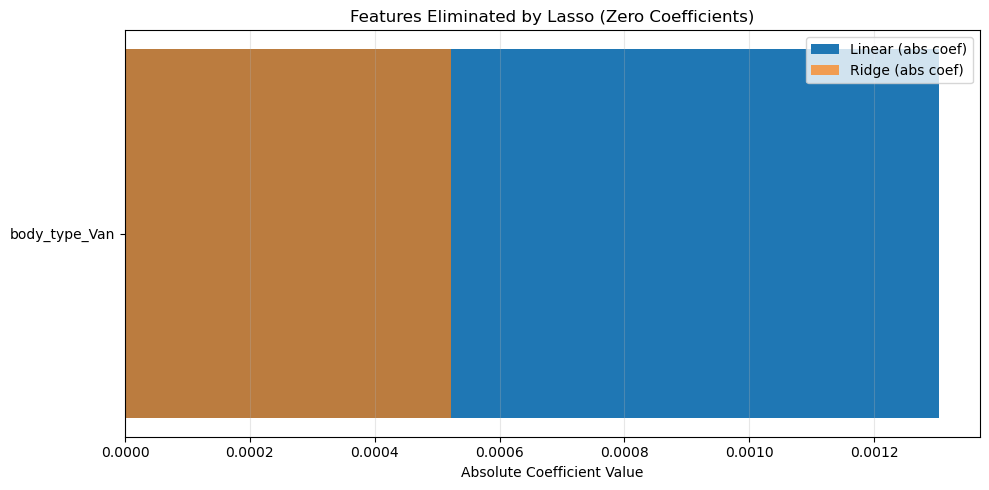

In [111]:
lasso_dropped = coef_comparison[coef_comparison['Lasso'] == 0]

# Plot only if there are eliminated features
if not lasso_dropped.empty:
    
    sample_dropped = lasso_dropped.head(10)  # limit for readability
    
    plt.figure(figsize=(10, 5))
    plt.barh(sample_dropped['Feature'], sample_dropped['Abs_Linear'], label='Linear (abs coef)')
    plt.barh(sample_dropped['Feature'], sample_dropped['Abs_Ridge'], label='Ridge (abs coef)', alpha=0.7)

    plt.xlabel('Absolute Coefficient Value')
    plt.title('Features Eliminated by Lasso (Zero Coefficients)')
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No features were completely eliminated by Lasso.")

## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

1. What did you notice by performing regularisation?

a) Regularisation reduced the magnitude of coefficients compared to the baseline Linear Regression.
b)  Regression shrunk coefficients but kept all features.
c) Lasso Regression shrunk some coefficients to exact zero, effectively removing less important features.

2.Did the model performance improve? If not, then why?

a) Yes, slightly.
b) Ridge Regression showed: Lower RMSE and MAE compared to Linear Regression.Slightly higher R² score.
c) Lasso Regression had performance close to Ridge but slightly lower in some cases due to feature elimination.
d) The baseline Linear Regression model was already performing reasonably well.The dataset is clean, complete, and well-structured (no missing values).
Important predictors such as age, km, hp_kW, and transmission type already explain a large portion of price variation.Therefore, regularisation mainly improved stability, not drastically accuracy.

4. Did you find overfitting or not?

a) No strong overfitting was observed.
b) Training and test performance were similar across models. However: Linear Regression showed slightly larger coefficients, indicating potential sensitivity to multicollinearity. Ridge helped control this by shrinking coefficients.

5. Was the data sufficient?
a) Yes.
b) The dataset contains 15,915 records, which is sufficient for linear and regularised regression.
c) The large sample size helps the model generalise well and reduces variance.

6. Is a linear model sufficient?
a) Yes, to a good extent.
b) Linear and regularised models achieved:
c) Good R² scores
d) Acceptable RMSE and MAE

This indicates that the relationship between features and price is approximately linear.